
Step 1: All required libraries imported successfully!

Step 2: Dataset loaded successfully into DataFrame 'df'!

FIRST 5 ROWS OF THE DATASET
   Unnamed: 0                                  Name  Rating  Spec_score                      No_of_sim       Ram            Battery     Display                                             Camera                     External_Memory Android_version   Price  company   Inbuilt_memory       fast_charging                              Screen_resolution             Processor Processor_name
0           0                 Samsung Galaxy F14 5G    4.65          68  Dual Sim, 3G, 4G, 5G, VoLTE,   4 GB RAM  6000 mAh Battery   6.6 inches    50 MP + 2 MP Dual Rear &amp; 13 MP Front Camera    Memory Card Supported, upto 1 TB              13   9,999  Samsung   128 GB inbuilt   25W Fast Charging   2408 x 1080 px Display with Water Drop Notch   Octa Core Processor    Exynos 1330
1           1                    Samsung Galaxy A11    4.20          63      Dual Sim, 3

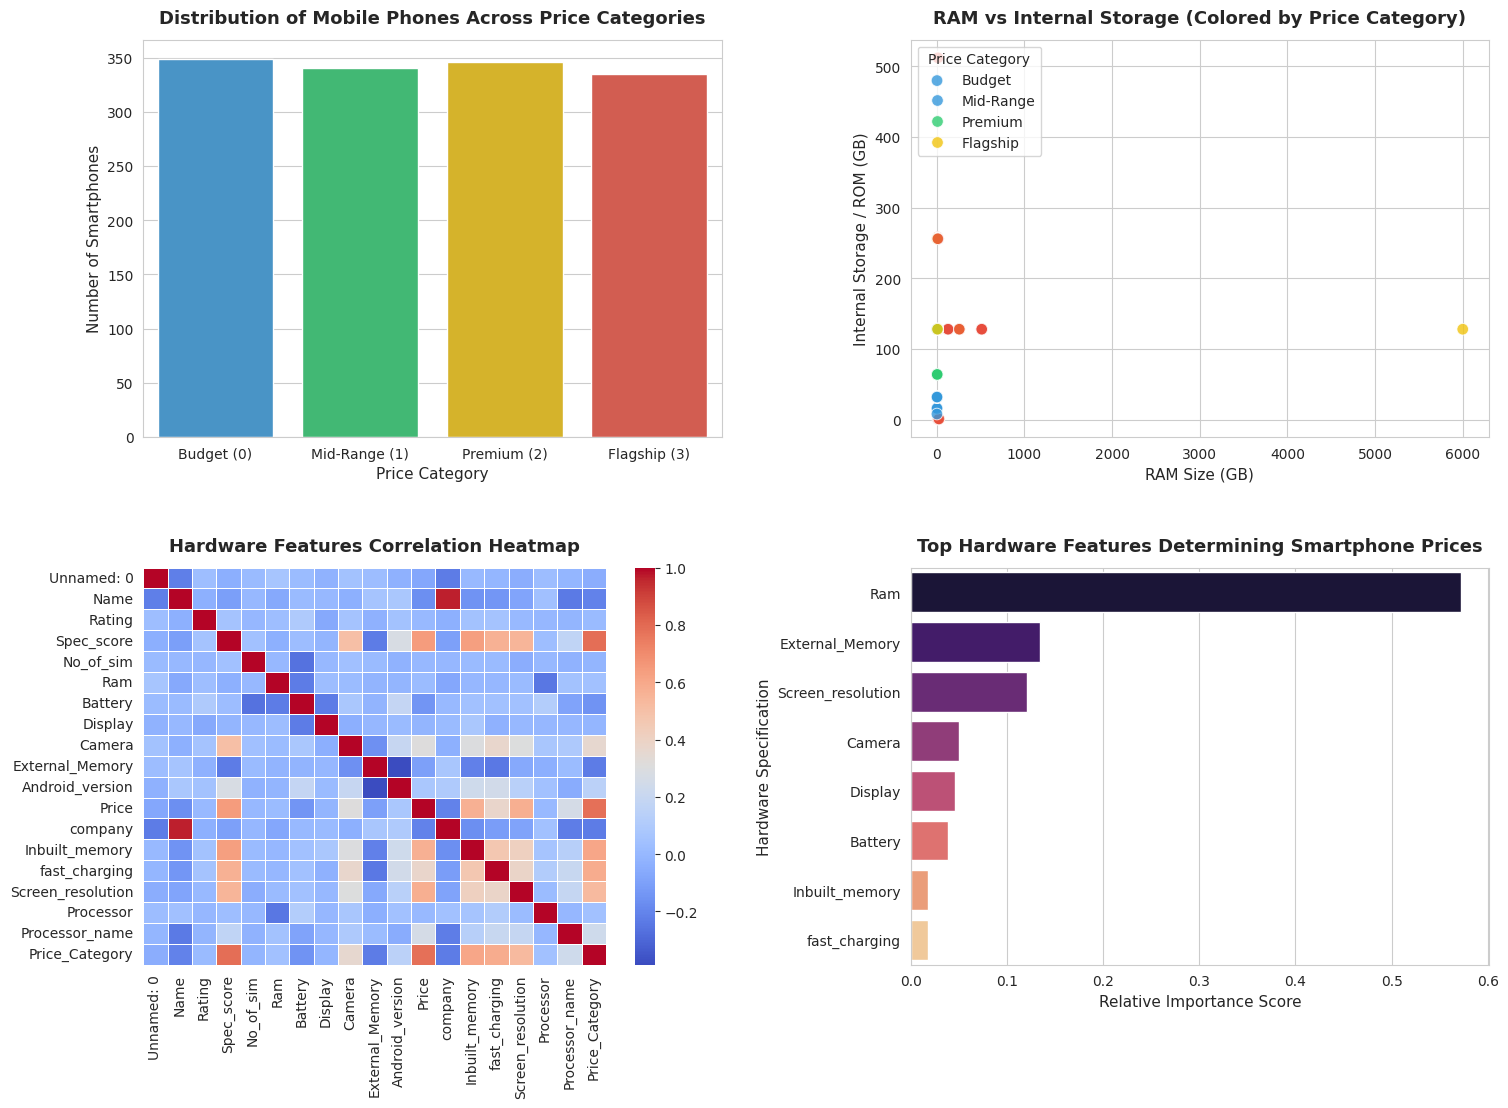

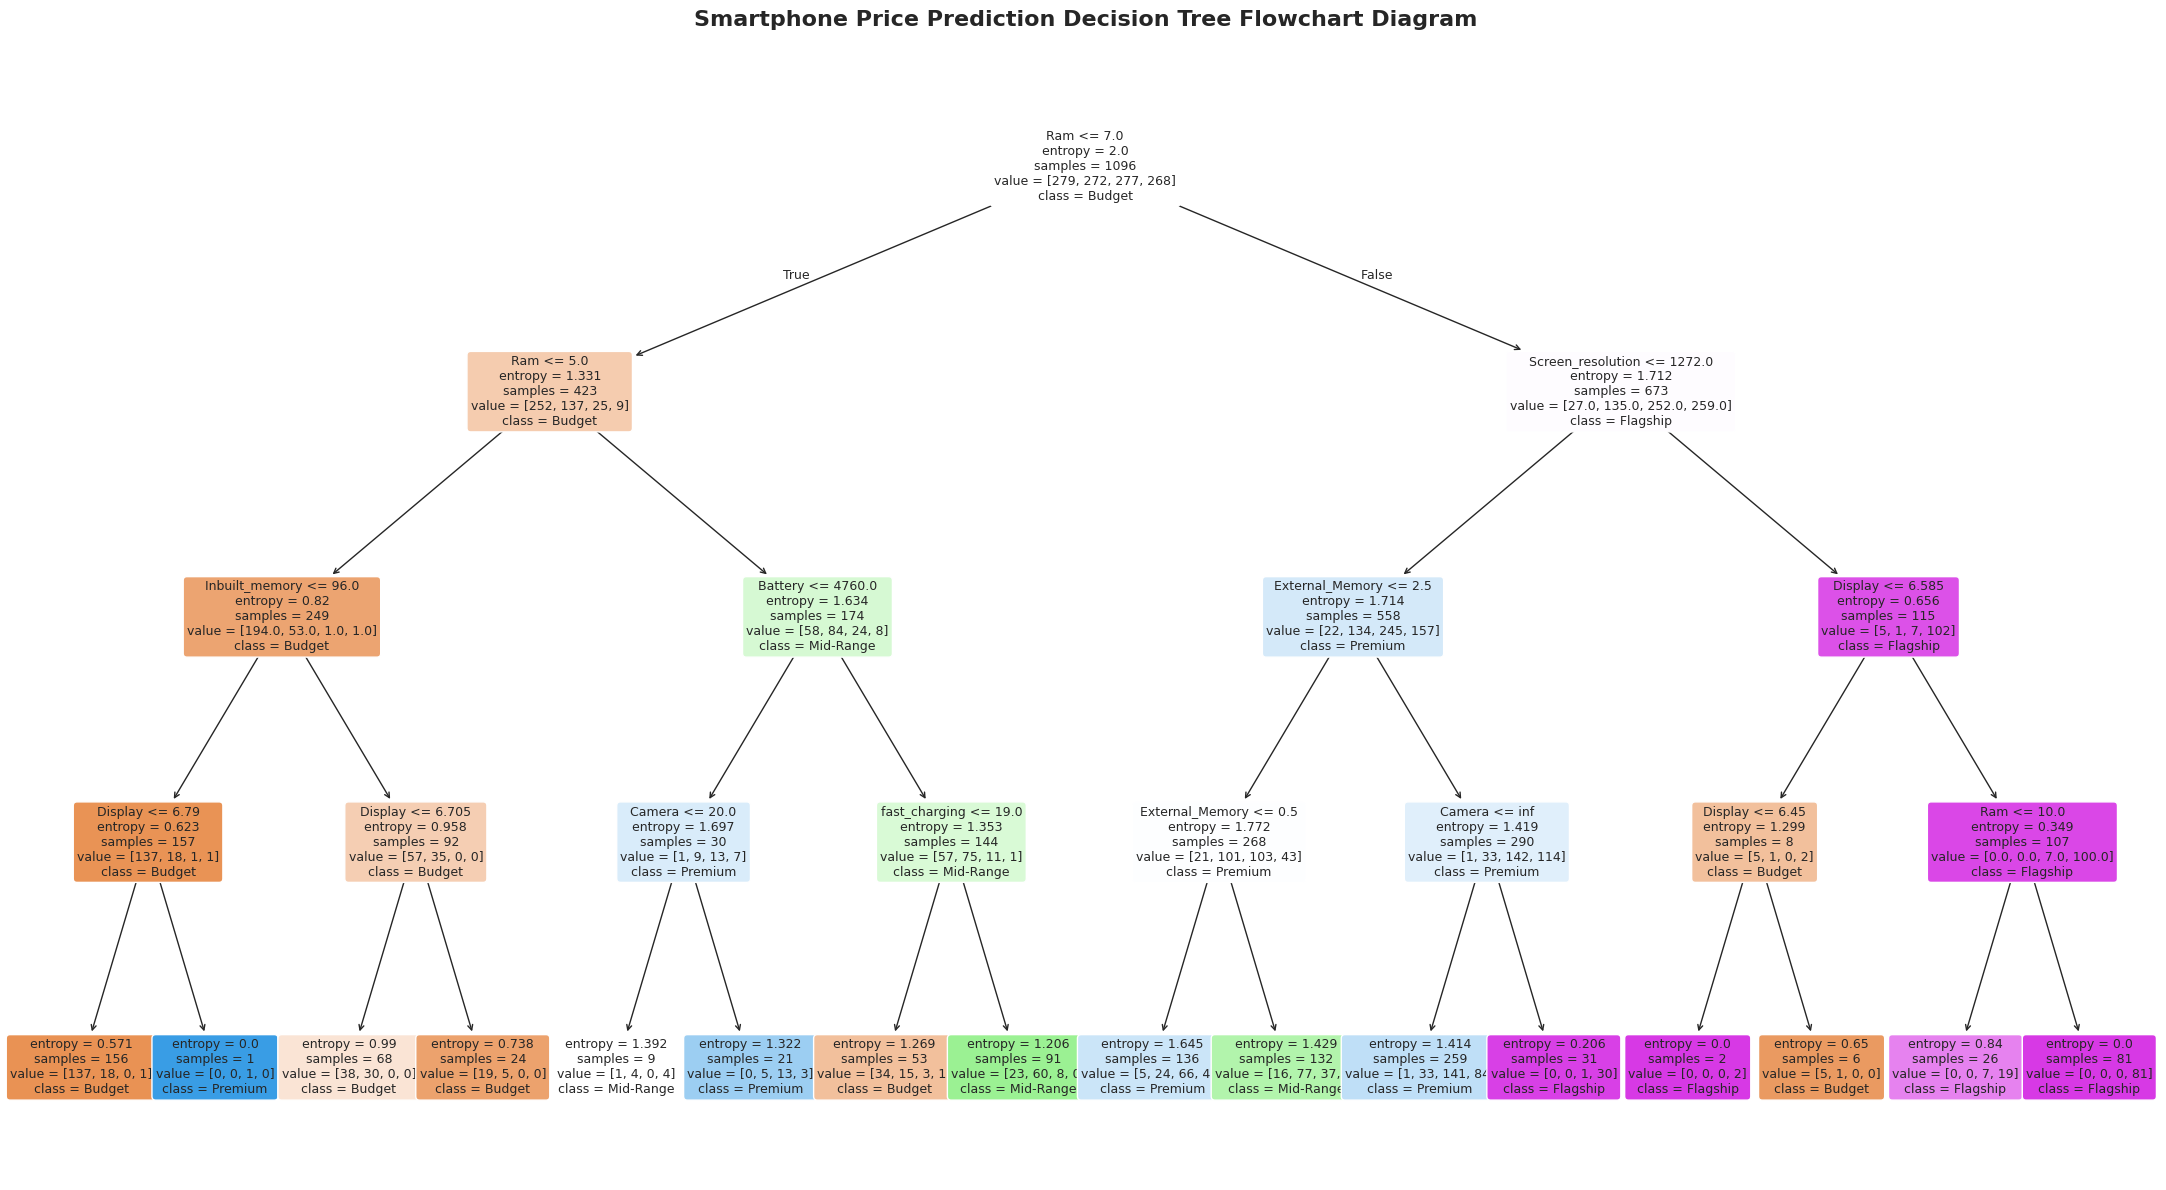


     INTERACTIVE SMARTPHONE PRICE PREDICTION ENGINE     
Type the hardware values below (Case-Insensitive):



KeyboardInterrupt: Interrupted by user

In [ ]:
# =================================================================================
# IBM INDUSTRIAL TRAINING MACHINE LEARNING PROJECT
# PROJECT NAME: SMARTPHONE PRICE CATEGORY PREDICTION SYSTEM BASED ON HARDWARE FEATURES
# Algorithm: Decision Tree Classification
# =================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configure Pandas display options so output tables do not wrap
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

print("\n" + "=" * 65)
print("Step 1: All required libraries imported successfully!")
print("=" * 65 + "\n")


# ============================================================
# Step 2: Loading the Dataset
# ============================================================

df = pd.read_csv('data.csv')

print("=" * 65)
print("Step 2: Dataset loaded successfully into DataFrame 'df'!")
print("=" * 65 + "\n")


# ============================================================
# Step 3: Displaying and Inspecting Dataset Structure
# ============================================================

print("=" * 65)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 65)
print(df.head())

print("\n" + "=" * 65)
print("LAST 5 ROWS OF THE DATASET")
print("=" * 65)
print(df.tail())

print("\n" + "=" * 65)
print("DATASET DIMENSIONS (SHAPE)")
print("=" * 65)
print("Total Mobile Phones (Rows)     :", df.shape[0])
print("Total Hardware Features (Cols)  :", df.shape[1])

print("\n" + "=" * 65)
print("HARDWARE FEATURE NAMES")
print("=" * 65)
print(df.columns.tolist())

print("\n" + "=" * 65)
print("DATA TYPES OF FEATURES")
print("=" * 65)
print(df.dtypes)


# ============================================================
# Step 4: Checking Missing Values & Statistical Summary
# ============================================================

print("\n" + "=" * 65)
print("MISSING VALUES CHECK (BEFORE CLEANING)")
print("=" * 65)

missing_vals = df.isnull().sum()

if missing_vals.sum() == 0:
    print("Zero missing values found! The dataset is complete and clean.")
else:
    print("Missing values per column:\n")
    print(missing_vals[missing_vals > 0])


# ============================================================
# Step 5: Data Cleaning & Screen Resolution Extraction
# ============================================================

# 1. Fill missing text values with Mode
df['Android_version'] = df['Android_version'].fillna(df['Android_version'].mode()[0])
df['Inbuilt_memory'] = df['Inbuilt_memory'].fillna(df['Inbuilt_memory'].mode()[0])
df['fast_charging'] = df['fast_charging'].fillna('No Fast Charging')
df['Screen_resolution'] = df['Screen_resolution'].fillna(df['Screen_resolution'].mode()[0])
df['Processor'] = df['Processor'].fillna(df['Processor'].mode()[0])

# 2. Clean Price
if df['Price'].dtype == 'object':
    df['Price'] = df['Price'].astype(str).str.replace(',', '').str.replace('₹', '').astype(float)

# 3. Extract Screen Resolution to pure pixels (e.g. '1080 X 2400' -> 1080)
if df['Screen_resolution'].dtype == 'object':
    df['Screen_resolution'] = df['Screen_resolution'].astype(str).str.extract(r'(\d{3,4})').astype(float)

# 4. Extract Battery mAh
if df['Battery'].dtype == 'object':
    df['Battery'] = df['Battery'].astype(str).str.extract(r'(\d+)').astype(float)

# 5. Extract Display size
if df['Display'].dtype == 'object':
    df['Display'] = df['Display'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# 6. Extract Camera MP
if df['Camera'].dtype == 'object':
    df['Camera'] = df['Camera'].astype(str).str.extract(r'(\d+)').astype(float)

# 7. Extract Inbuilt Memory
if df['Inbuilt_memory'].dtype == 'object':
    df['Inbuilt_memory'] = df['Inbuilt_memory'].astype(str).str.extract(r'(\d+)').astype(float)

# 8. Extract External Memory
if df['External_Memory'].dtype == 'object':
    df['External_Memory'] = df['External_Memory'].astype(str).str.extract(r'(\d+)').fillna(0).astype(float)

# 9. Extract Android version
if df['Android_version'].dtype == 'object':
    df['Android_version'] = df['Android_version'].astype(str).str.extract(r'(\d+)').astype(float)

# 10. Extract Fast Charging Wattage
if df['fast_charging'].dtype == 'object':
    df['fast_charging'] = df['fast_charging'].astype(str).str.extract(r'(\d+)').fillna(0).astype(float)

# 11. Extract RAM
if df['Ram'].dtype == 'object':
    df['Ram'] = df['Ram'].astype(str).str.extract(r'(\d+)').astype(float)

# 12. Extract SIMs count
if df['No_of_sim'].dtype == 'object':
    df['No_of_sim'] = df['No_of_sim'].astype(str).str.extract(r'(\d+)').fillna(2).astype(float)

# 13. Clean Processor_name
if 'Processor_name' in df.columns and df['Processor_name'].dtype == 'object':
    df['Processor_name'] = df['Processor_name'].astype(str).str.replace(r'.*ram.*', 'Standard Processor', case=False, regex=True)

print("\n" + "=" * 65)
print("MISSING VALUES CHECK (AFTER CLEANING)")
print("=" * 65)
print("Total Missing Values Remaining :", df.isnull().sum().sum())


# ============================================================
# Step 6: Encoding Categorical Text Columns
# ============================================================

categorical_cols = df.select_dtypes(include=['object']).columns

print("\n" + "=" * 65)
print("ENCODING CATEGORICAL TEXT COLUMNS")
print("=" * 65)
print("True Categorical Columns Remaining :", categorical_cols.tolist())

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str).str.lower().str.strip())
    label_encoders[col] = le

print("\nCategorical Encoding Completed Successfully!")


# ============================================================
# Step 7: Creating Price Categories for Classification
# ============================================================

# Convert continuous Price into 4 equal price categories (0, 1, 2, 3)
df['Price_Category'] = pd.qcut(df['Price'], q=4, labels=[0, 1, 2, 3])

print("\n" + "=" * 65)
print("PRICE CATEGORY DISTRIBUTION (0: Budget -> 3: Flagship)")
print("=" * 65)
print(df['Price_Category'].value_counts())


# ============================================================
# Step 8: Separate Input Features (X) and Target (y)
# ============================================================

# Drop non-hardware & post-purchase columns (Rating, Spec_score, Name, Processor_name, Index, Price)
cols_to_drop = ['Price', 'Price_Category', 'Unnamed: 0', 'Name', 'Rating', 'Spec_score', 'Processor_name']

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df['Price_Category']

print("\n" + "=" * 65)
print("CLEAN HARDWARE FEATURES SELECTED FOR MODEL TRAINING:")
print("=" * 65)
print(X.columns.tolist())


# ============================================================
# Step 9: Train-Test Split (80% Training, 20% Testing)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 65)
print("TRAIN-TEST DATA SPLIT COMPLETED")
print("=" * 65)
print("Training Samples (80% of data) :", X_train.shape[0])
print("Testing Samples (20% of data)  :", X_test.shape[0])


# ============================================================
# Step 10: Create and Train Decision Tree Classifier
# ============================================================

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("\n" + "=" * 65)
print("DECISION TREE MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("=" * 65)


# ============================================================
# Step 11: Making Predictions & Calculating Accuracy
# ============================================================

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 65)
print("MODEL ACCURACY RESULTS")
print("=" * 65)
print("Accuracy Score      :", round(accuracy, 4))
print("Accuracy Percentage :", round(accuracy * 100, 2), "%")


# ============================================================
# Step 12: Detailed Evaluation Metrics
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\n" + "=" * 65)
print("CONFUSION MATRIX")
print("=" * 65)
print(cm)

print("\n" + "=" * 65)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(
    y_test,
    y_pred,
    target_names=['Budget', 'Mid-Range', 'Premium', 'Flagship']
))


# ============================================================
# Step 13: Exploratory Data Analysis & Model Visualizations (2x2 Grid)
# ============================================================

sns.set_style("whitegrid")

# Create a large 16x12 figure canvas for 4 subplots
plt.figure(figsize=(16, 12))


# ------------------------------------------------------------
# Subplot 1 (Top-Left): Price Category Distribution Count Plot
# ------------------------------------------------------------
plt.subplot(2, 2, 1)

sns.countplot(
    x=y,
    hue=y,
    palette=['#3498db', '#2ecc71', '#f1c40f', '#e74c3c'],
    legend=False
)

plt.title("Distribution of Mobile Phones Across Price Categories", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Price Category", fontsize=11)
plt.ylabel("Number of Smartphones", fontsize=11)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Budget (0)', 'Mid-Range (1)', 'Premium (2)', 'Flagship (3)'])


# ------------------------------------------------------------
# Subplot 2 (Top-Right): Scatter Plot - RAM vs Storage
# ------------------------------------------------------------
plt.subplot(2, 2, 2)

sns.scatterplot(
    x='Ram',
    y='Inbuilt_memory',
    hue='Price_Category',
    data=df,
    palette=['#3498db', '#2ecc71', '#f1c40f', '#e74c3c'],
    s=70,
    alpha=0.8
)

plt.title("RAM vs Internal Storage (Colored by Price Category)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("RAM Size (GB)", fontsize=11)
plt.ylabel("Internal Storage / ROM (GB)", fontsize=11)
plt.legend(title="Price Category", labels=['Budget', 'Mid-Range', 'Premium', 'Flagship'], loc='upper left')


# ------------------------------------------------------------
# Subplot 3 (Bottom-Left): Correlation Matrix Heatmap
# ------------------------------------------------------------
plt.subplot(2, 2, 3)

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Hardware Features Correlation Heatmap", fontsize=13, fontweight='bold', pad=12)


# ------------------------------------------------------------
# Subplot 4 (Bottom-Right): Feature Importance Bar Plot
# ------------------------------------------------------------
plt.subplot(2, 2, 4)

importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Hardware_Feature': X.columns,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False).head(8)

sns.barplot(
    x='Importance_Score',
    y='Hardware_Feature',
    hue='Hardware_Feature',
    data=feature_importance_df,
    palette='magma',
    legend=False
)

plt.title("Top Hardware Features Determining Smartphone Prices", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Relative Importance Score", fontsize=11)
plt.ylabel("Hardware Specification", fontsize=11)

# Set padding between subplots to ensure clear layout separation
plt.tight_layout(pad=4.0)
plt.show()


# ============================================================
# Step 14: Decision Tree Flowchart Diagram
# ============================================================

plt.figure(figsize=(22, 12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Budget', 'Mid-Range', 'Premium', 'Flagship'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Smartphone Price Prediction Decision Tree Flowchart Diagram", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# ============================================================
# Step 15: Clean, Interactive Price Predictor
# ============================================================

print("\n" + "=" * 65)
print("     INTERACTIVE SMARTPHONE PRICE PREDICTION ENGINE     ")
print("=" * 65)
print("Type the hardware values below (Case-Insensitive):\n")

prompt_hints = {
    'No_of_sim': "Number of SIMs [NUMBER] (e.g. 1 or 2) : ",
    'Ram': "RAM Size [NUMBER] (in GB, e.g. 6 or 8) : ",
    'Battery': "Battery Capacity [NUMBER] (in mAh, e.g. 5000) : ",
    'Display': "Display Screen Size [NUMBER] (in inches, e.g. 6.5) : ",
    'Camera': "Primary Camera Resolution [NUMBER] (in MP, e.g. 50 or 64) : ",
    'External_Memory': "External Storage Limit [NUMBER] (in GB, e.g. 512 or 0) : ",
    'Android_version': "Android OS Version [NUMBER] (e.g. 11 or 12) : ",
    'Inbuilt_memory': "Internal Storage / ROM [NUMBER] (in GB, e.g. 128 or 256) : ",
    'fast_charging': "Fast Charging Wattage [NUMBER] (in Watts, e.g. 18, 33, 67) : ",
    'Screen_resolution': "Screen Resolution [NUMBER] (720 for HD, 1080 for FHD, 1440 for 2K) : "
}

user_inputs = {}

for col in X.columns:
    if col in label_encoders:
        # Show ALL available trained options in clean Title Case
        all_options = sorted(list(set([str(opt).title() for opt in label_encoders[col].classes_])))
        opts_str = ", ".join(all_options)

        print("-" * 65)
        print(f"Feature: {col}")
        print(f"ALL AVAILABLE CHOICES: {opts_str}")
        val_input = input(f"Enter Choice for {col} (Any case works) : ").strip().lower()
        print("-" * 65)

        trained_classes = [str(c).lower() for c in label_encoders[col].classes_]

        matched = False
        for idx, cls_name in enumerate(trained_classes):
            if val_input in cls_name or cls_name in val_input:
                user_inputs[col] = label_encoders[col].transform([cls_name])[0]
                matched = True
                break

        if not matched:
            print(f"  [Note] '{val_input.title()}' not in training list. Using default category.")
            user_inputs[col] = 0

    else:
        # Prompt for numerical hardware specs
        prompt_msg = prompt_hints.get(col, f"{col} [NUMBER] : ")
        val_input = input(f"Enter {prompt_msg}").strip()
        try:
            user_inputs[col] = float(val_input)
        except ValueError:
            user_inputs[col] = 0.0

# Convert user input to DataFrame
user_df = pd.DataFrame([user_inputs])

# Predict Price Category using Trained Decision Tree Model
pred_code = model.predict(user_df)[0]

# Mapping predicted category codes to readable names & rupee price ranges
category_details = {
    0: ("Budget Phone", "₹5,000 - ₹12,000 (Low Cost)"),
    1: ("Mid-Range Phone", "₹12,000 - ₹25,000 (Mid-Range)"),
    2: ("Premium Mid-Range", "₹25,000 - ₹45,000 (Upper Mid-Range)"),
    3: ("Flagship Phone", "₹45,000+ (High Cost)")
}

seg_name, price_bracket = category_details.get(pred_code, ("Unknown Category", "N/A"))

# Display Clean Output Card
print("\n" + "=" * 65)
print("             SMARTPHONE PRICE PREDICTION RESULT             ")
print("=" * 65)
print("PREDICTED CATEGORY CODE :", pred_code)
print("PREDICTED PRICE SEGMENT :", seg_name)
print("ESTIMATED PRICE RANGE   :", price_bracket)
print("=" * 65 + "\n")


# ============================================================
# Step 16: Project Completion Summary
# ============================================================

print("\n" + "=" * 65)
print("  SMARTPHONE PRICE CATEGORY PREDICTION SYSTEM COMPLETED SUCCESS")
print("  IBM Industrial Training Machine Learning Project Finished")
print("=" * 65 + "\n")